In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.cluster.hierarchy import fcluster, linkage, dendrogram, cut_tree, leaves_list
from scipy.spatial.distance import pdist, squareform

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()

if BASE_DIR.name == "Notebooks":
    BASE_DIR = BASE_DIR.parent

DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"
DOC_DIR = BASE_DIR / "Docs"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [5]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [6]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [7]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

**Distance de Jaccard entre thèmes**

In [8]:
# la distance de Jaccard est calculée entre toutes les paires de lignes :
# 65 thèmes => [65 x (65-1)]/2 paires (=2080)

MT = matrix_themes.T.to_numpy().astype(bool)

dist_jaccard_T = pdist(
    MT, 
    metric="jaccard"
)

**Clustering hiérarchique**

In [9]:
# linkage sur matrice de Jaccard

LT = linkage(
    dist_jaccard_T, 
    method="average"
)

**Dendrogramme des thèmes**

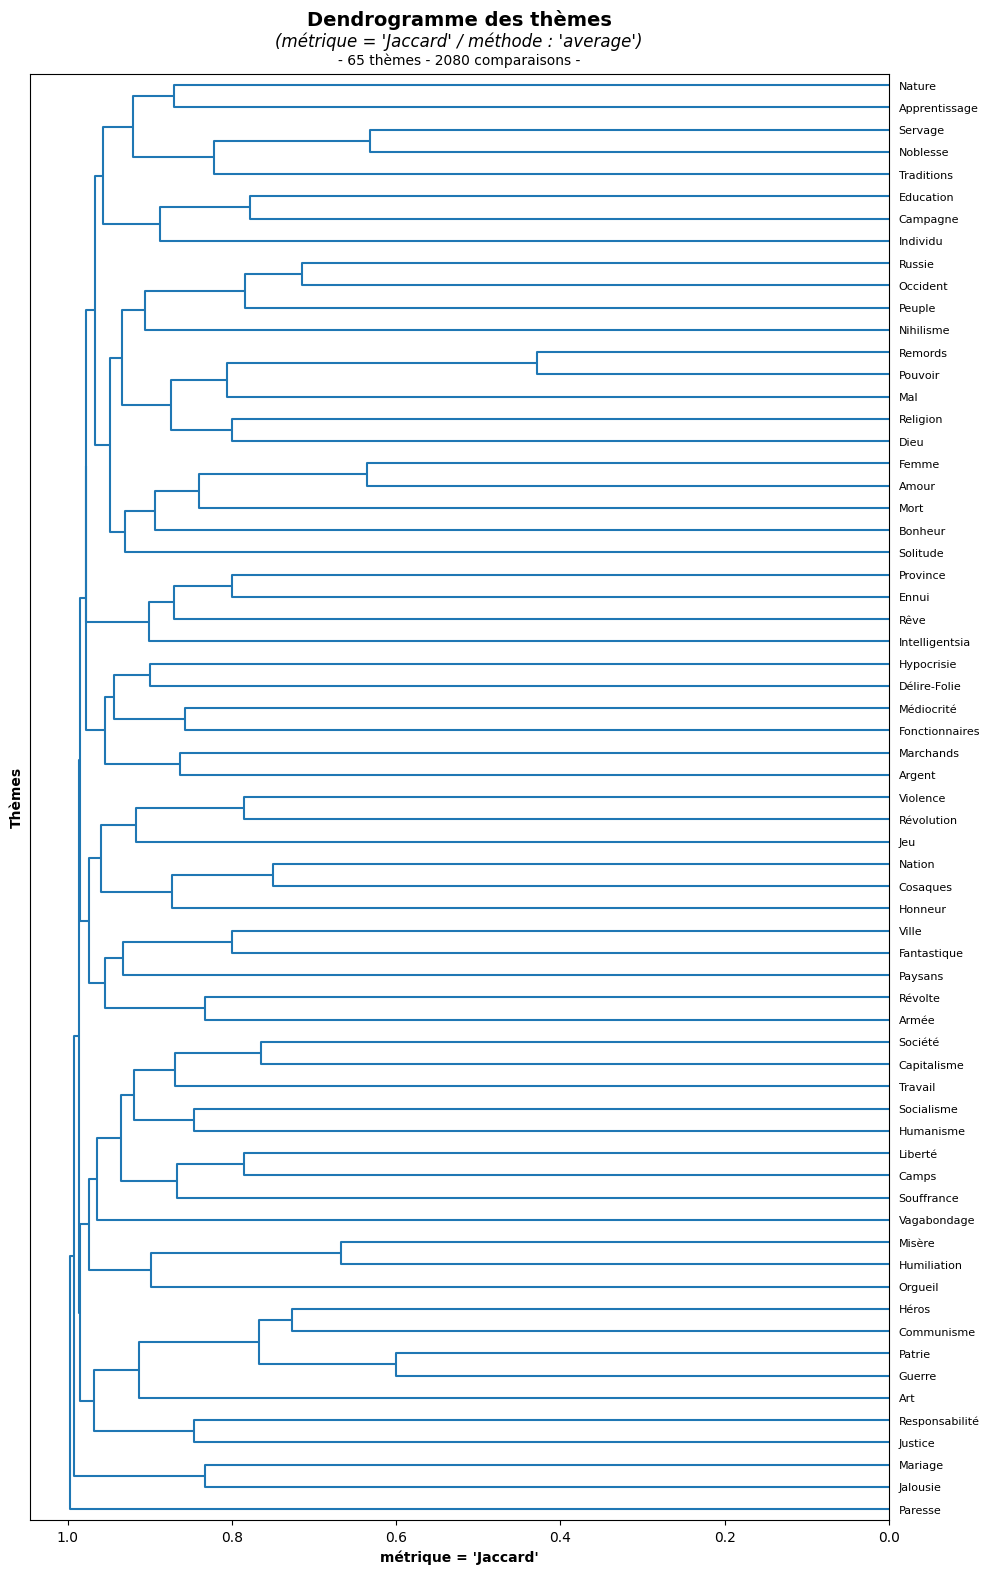

In [11]:
N_themes = len(the_themes)
N_dist_jaccard_T = len(dist_jaccard_T)

fig, ax = plt.subplots(figsize=(10, 16))

dendrogram(
    LT,
    labels=the_themes,
    leaf_rotation=0, 
    leaf_font_size=8,
    orientation="left",
    color_threshold=0
)

ax.set_ylabel("Thèmes", fontweight="bold")
ax.set_xlabel("métrique = 'Jaccard'", fontweight="bold")
ax.tick_params(axis="x", labelsize=10)

fig.tight_layout(rect=[0, 0, 1, 0.95])

titres(
    fig,
    ax,
    t1="Dendrogramme des thèmes", y1=35,
    t2="(métrique = 'Jaccard' / méthode : 'average')", y2=20,
    t3=f"- {N_themes} thèmes - {N_dist_jaccard_T} comparaisons -", y3=7
)

fig.savefig(
    IMG_DIR / "thèmes_dendrogramme.png", 
    dpi=300,
    bbox_inches="tight")

plt.show()

**Bloc complet : Analyse des distances de Jaccard entre thèmes**

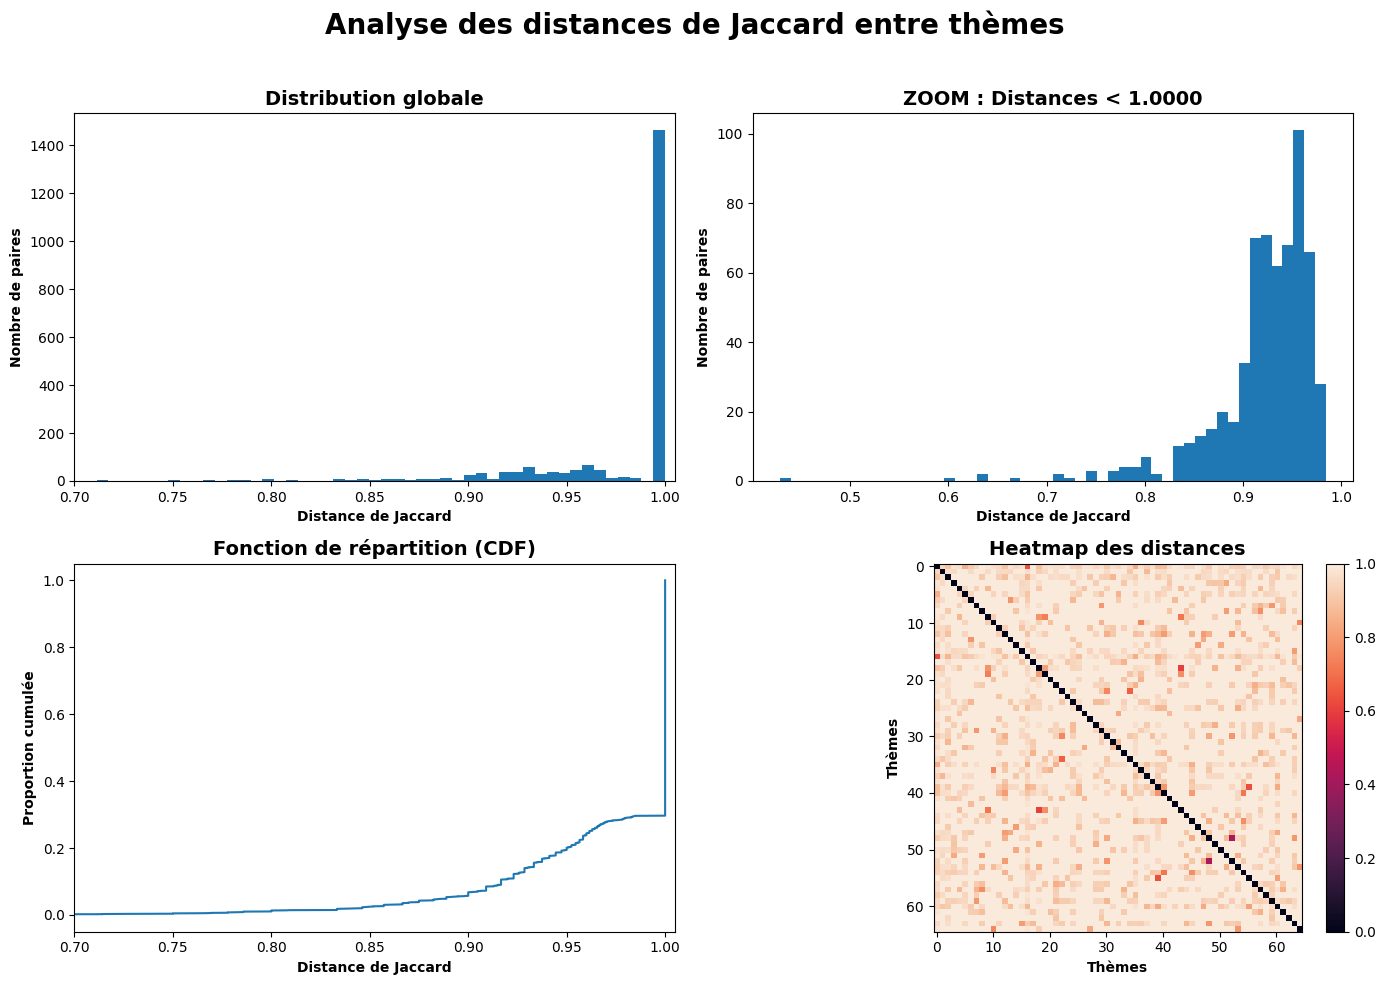

In [12]:
# =========================
# Préparation des données
# =========================

# distance de Jaccard entre les THEMES
dist = dist_jaccard_T

# dist : array (forme condensée)
dist_array = dist.copy()

# matrice carrée
dist_matrix = squareform(dist_array)

# tri pour la CDF
sorted_dist = np.sort(dist_array)
cdf = np.arange(len(sorted_dist)) / len(sorted_dist)

# sélection des petites distances (zone informative)
threshold = np.percentile(dist_array, 30)
small_dist = dist_array[dist_array < threshold]

# =========================
# Création des subplots
# =========================

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Analyse des distances de Jaccard entre thèmes", fontsize=20, fontweight="bold")

# =========================
# (1) Histogramme global
# =========================

ax[0, 0].hist(dist_array, bins="auto")
ax[0, 0].set_title("Distribution globale", fontsize=14, fontweight="bold")
ax[0, 0].set_xlabel("Distance de Jaccard", fontweight="bold")
ax[0, 0].set_ylabel("Nombre de paires", fontweight="bold")
ax[0, 0].set_xlim(0.7, 1.005)

# =========================
# (2) Histogramme zoom
# =========================

ax[0, 1].hist(small_dist, bins="auto")
ax[0, 1].set_title(f"ZOOM : Distances < {threshold:.4f}", fontsize=14, fontweight="bold")
ax[0, 1].set_xlabel("Distance de Jaccard", fontweight="bold")
ax[0, 1].set_ylabel("Nombre de paires", fontweight="bold")

# =========================
# (3) CDF
# =========================

ax[1, 0].plot(sorted_dist, cdf)
ax[1, 0].set_title("Fonction de répartition (CDF)", fontsize=14, fontweight="bold")
ax[1, 0].set_xlabel("Distance de Jaccard", fontweight="bold")
ax[1, 0].set_ylabel("Proportion cumulée", fontweight="bold")
ax[1, 0].set_xlim(0.7, 1.005)


# =========================
# (4) Heatmap
# =========================

im = ax[1, 1].imshow(dist_matrix, cmap="rocket")
ax[1, 1].set_title("Heatmap des distances", fontsize=14, fontweight="bold")
ax[1, 1].set_xlabel("Thèmes", fontweight="bold")
ax[1, 1].set_ylabel("Thèmes", fontweight="bold")

# barre de couleur
fig.colorbar(im, ax=ax[1, 1], fraction=0.046, pad=0.04)

# =========================
# Finition propre
# =========================

fig.tight_layout(rect=[0, 0, 1, 0.96])
                      
fig.savefig(
    IMG_DIR / "thèmes_analyse_distances_Jaccard.png", 
    dpi=300,
    bbox_inches="tight")

plt.show()

**Plot distances de Jaccard par rapport à la valeur 1**

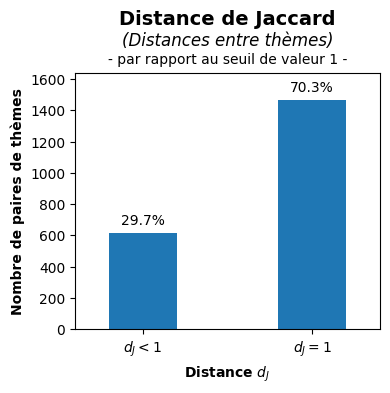

In [13]:

d_eq1 = np.sum(dist == 1)
d_lt1 = np.sum(dist < 1)

counts = [d_lt1, d_eq1]
labels = [r"$d_J < 1$", r"$d_J = 1$"]

# géométrie réelle
x = [0.00, 0.25]

fig, ax = plt.subplots(figsize=(4,4))

bars = ax.bar(
    x,
    counts,
    width=0.10      # largeur des objets
)

# % au-dessus des barres
total = sum(counts)

percent_labels = [
    f"{100*c/total:.1f}%"
    for c in counts
]

ax.bar_label(
    bars,
    labels=percent_labels,
    padding=4,
    fontsize=10
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_xlabel(r"Distance $d_J$", fontweight="bold")
ax.set_ylabel("Nombre de paires de thèmes", fontweight="bold")

# cadrage esthétique
ax.set_ylim(0, max(counts)*1.12)

margin = 0.10

ax.set_xlim(
    min(x)-margin,
    max(x)+margin
)

fig.tight_layout(rect=[0, 0, 1, 0.85])

titres(
    fig,
    ax,
    t1="Distance de Jaccard", y1=35,
    t2="(Distances entre thèmes)", y2=20,
    t3="- par rapport au seuil de valeur 1 -", y3=7
)

fig.savefig(
    IMG_DIR / "thèmes_dist_Jaccard_valeur_1.png", 
    dpi=300,
    bbox_inches="tight")

plt.show()

**Réordonner la heatmap des distance de Jaccard avec clustering hiérarchique**

In [14]:

# ==============================================
# Mise en ordre des thèmes selon le dendrogramme
# ==============================================

# array des distances de Jaccard
dist_array = dist_jaccard_T.copy()

# formation en matrice carrée
dist_matrix = squareform(dist_array)

# -----
# ces instructions appliquent le même ordre aux lignes et aux colonnes, 
# ce qui fait apparaître les blocs de thèmes proches le long de la diagonale

# ordre des thèmes selon le dendrogramme
ordered_idx = leaves_list(LT)
reordered_idx = np.flip(ordered_idx)

# matrice réordonnée
dist_matrix_reordered = dist_matrix[reordered_idx, :][:, reordered_idx]
# -----

# avec les noms des thèmes
theme_names_reordered = np.array(the_themes)[reordered_idx]


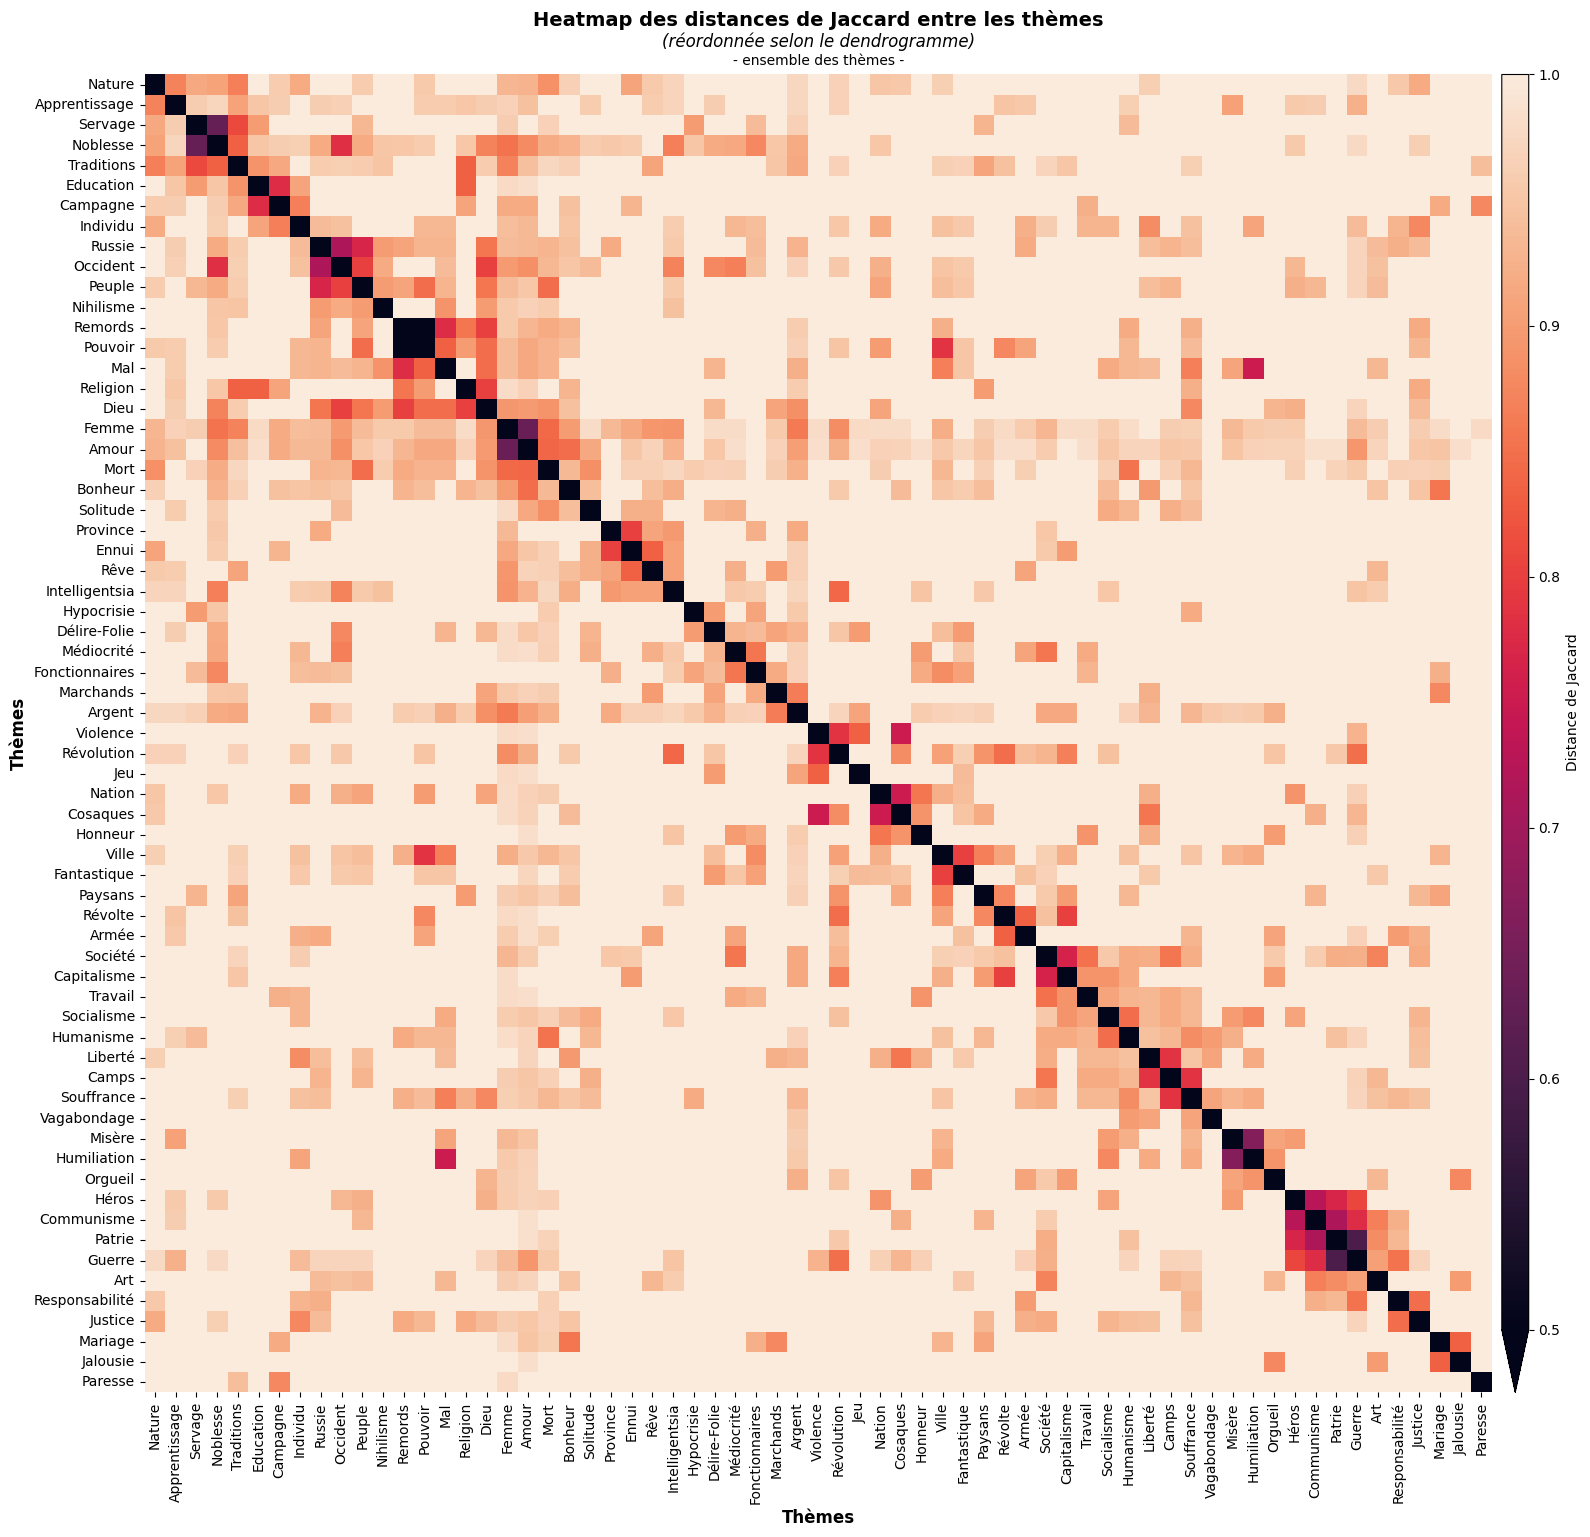

In [15]:

# ===========================================================
# Heatmap réordonnée selon l'ordre des thèmes du dendrogramme
# ===========================================================

fig, ax = plt.subplots(figsize=(16, 16))

sns.heatmap(
    dist_matrix_reordered,
    cmap="rocket",
    cbar=False,
    vmin=0.5,
    vmax=1,
    ax=ax
)

im = ax.collections[0]

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="2%",   # largeur de la colorbar
    pad=0.10     # distance au graphique
)

cbar = fig.colorbar(
    im,
    cax=cax,
    ticks=np.arange(0.5, 1.01, 0.1),
    extend="min"
)
cbar.set_label("Distance de Jaccard", fontsize=10)
cbar.ax.tick_params(labelsize=10)

# labels des thèmes
n = len(theme_names_reordered)

ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)

ax.set_xticklabels(theme_names_reordered, rotation=90, fontsize=10)
ax.set_yticklabels(theme_names_reordered, rotation=0, fontsize=10)

ax.set_xlabel("Thèmes", fontsize=12, fontweight="bold")
ax.set_ylabel("Thèmes", fontsize=12, fontweight="bold")

fig.tight_layout(rect=[0, 0, 1, 0.93]) # réserve de la place au-dessus du graphique

titres(
    fig,
    ax,
    t1="Heatmap des distances de Jaccard entre les thèmes", y1=35,
    t2="(réordonnée selon le dendrogramme)", y2=20,
    t3="- ensemble des thèmes -", y3=7
)

fig.savefig(
    IMG_DIR / "thèmes_heatmap_réordonnée_clustering.png", 
    dpi=300, 
    bbox_inches="tight")

plt.show()